In [1]:
from shimnet.generators import TheoreticalMultipletSpectraGenerator, ResponseGenerator, NoiseGenerator, Generator

In [2]:
from omegaconf import OmegaConf
from hydra.utils import instantiate
import torch
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

### noise

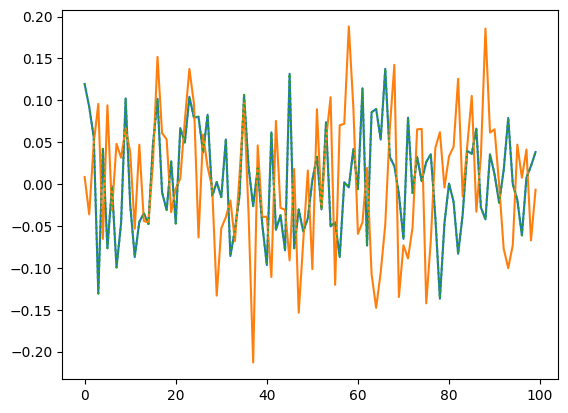

In [3]:
noise_generator_config = OmegaConf.create({
    "_target_": "shimnet.generators.NoiseGenerator",
    "spectrum_noise_min": 0.01,
    "spectrum_noise_max": 0.1,
    "seed": 42
})

sample_spectrum = torch.zeros(1,1,100)

noise_generator = instantiate(noise_generator_config)
noisy_spectrum = noise_generator(sample_spectrum)
plt.plot(noisy_spectrum[0, 0].detach().numpy())

noisy_spectrum = noise_generator(sample_spectrum)
plt.plot(noisy_spectrum[0, 0].detach().numpy())

noise_generator = instantiate(noise_generator_config)
noisy_spectrum = noise_generator(sample_spectrum)
plt.plot(noisy_spectrum[0, 0].detach().numpy(), ls=":")

# Expected: if seed is None all three lines are different. If seed is a number, lines 1 and 3 are the same


### response

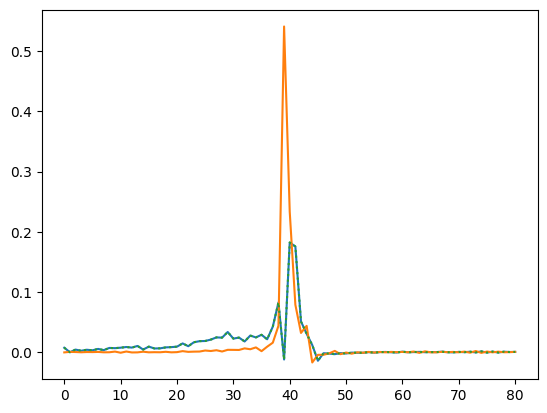

In [4]:
response_generator_config = OmegaConf.create({
    "_target_": "shimnet.generators.ResponseGenerator",
    "response_function_library": {
        "_target_": "shimnet.generators.ResponseLibrary",
        "response_files": [
            "../data/scrf_81_600MHz.pt"
        ]
    },
    "seed": 42
})

response_generator = instantiate(response_generator_config)
random_response = response_generator()
plt.plot(random_response.detach().numpy()[0,0])

random_response = response_generator()
plt.plot(random_response.detach().numpy()[0,0])

response_generator = instantiate(response_generator_config)
random_response = response_generator()
plt.plot(random_response.detach().numpy()[0,0], ls=":")

# Expected: if seed is None all three lines are different. If seed is a number, lines 1 and 3 are the same


### clean spectrum from multiplets

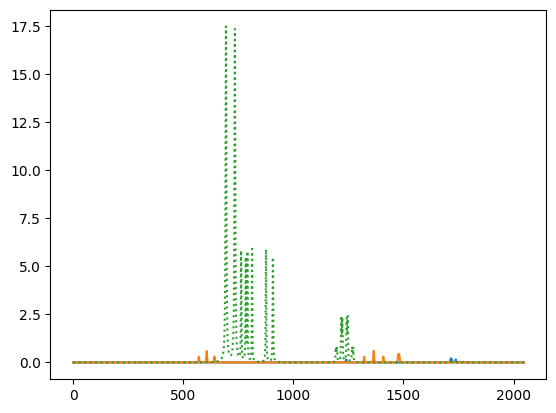

In [5]:
theoretical_generator_config = OmegaConf.create({
    "_target_": "shimnet.generators.TheoreticalMultipletSpectraGenerator",
    "atom_groups_data_file": "../data/multiplets_10000_parsed.txt",
    "seed": None
})

theoretical_generator = instantiate(theoretical_generator_config)
theoretical_spectrum, theoretical_spectrum_params = theoretical_generator()
plt.plot(theoretical_spectrum[0].detach().numpy())

theoretical_spectrum, theoretical_spectrum_params = theoretical_generator()
plt.plot(theoretical_spectrum[0].detach().numpy())

theoretical_generator = instantiate(theoretical_generator_config)
theoretical_spectrum, theoretical_spectrum_params = theoretical_generator()
plt.plot(theoretical_spectrum[0].detach().numpy(), ls=":")
# Expected: if seed is None all three lines are different. If seed is a number, lines 1 and 3 are the same


### Full data generator

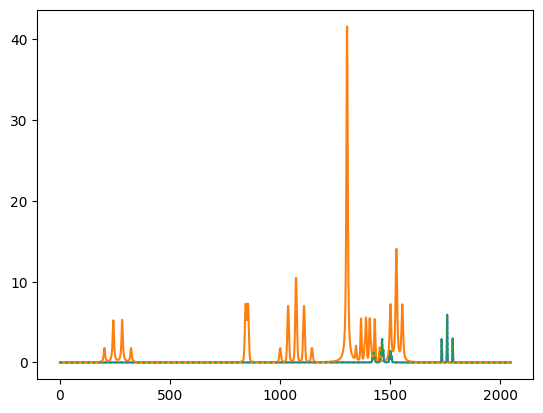

In [6]:
data_generator_config = OmegaConf.create({
    "_target_": "shimnet.generators.Generator",
    "clean_spectra_generator": theoretical_generator_config,
    "response_generator": response_generator_config,
    "noise_generator": noise_generator_config,
    "include_spectrum_data": False,
    "include_peak_mask": False,
    "include_response_function": False,
    "seed": 12,
    "batch_size": 3
})

data_generator = instantiate(data_generator_config)

data_iterator = iter(data_generator)

batch = next(data_iterator)
plt.plot(batch["theoretical_spectrum"][0,0])

batch = next(data_iterator)
plt.plot(batch["theoretical_spectrum"][0,0])

data_generator = instantiate(data_generator_config)
batch = next(iter(data_generator))
plt.plot(batch["theoretical_spectrum"][0,0], ls=":")

# Expected: if seed is None all three lines are different. If seed is a number, lines 1 and 3 are the same


## Speed benchmark

In [7]:
from datetime import datetime
from shimnet.generators import get_datapipe

In [9]:
config_modular = OmegaConf.load("../configs/shimnet_600_modular.yaml").data
config_standard = OmegaConf.load("../configs/shimnet_600.yaml").data

config_standard.response_functions_files = ["../" + p for p in config_standard.response_functions_files]
config_standard.atom_groups_data_file = "../" + config_standard.atom_groups_data_file

config_modular.clean_spectra_generator.atom_groups_data_file = "../" + config_modular.clean_spectra_generator.atom_groups_data_file
config_modular.response_generator.response_function_library.response_files = ["../" + p for p in config_modular.response_generator.response_function_library.response_files]

In [14]:
batch_size = 512
config_modular.batch_size = batch_size

data_generators = {
    "standard": get_datapipe(**config_standard, batch_size=batch_size, include_response_function=True),
    "modular": instantiate(config_modular)
}


In [15]:
n_batches = 50

timings = {}
for k, generator in data_generators.items():
    # print(f"Timing data generator: {k}")
    data_iterator = iter(generator)
    start_time = datetime.now()
    for i in range(n_batches):
        batch = next(data_iterator)
    total_seconds = (datetime.now() - start_time).total_seconds()
    timings[k] = total_seconds
    print(f"  Time for {n_batches} batches of size {batch_size}: {total_seconds:.2f} seconds")

  Time for 50 batches of size 512: 30.57 seconds
  Time for 50 batches of size 512: 28.14 seconds
